<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-27-pca-on-mnist-using-scikit-learn?scriptVersionId=341645569" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 27 — PCA on MNIST Using Scikit-learn

### **From 784 Pixels to Principal Components**

---



# 📌 Introduction

> In this notebook, we will apply **Principal Component Analysis (PCA)** to the **MNIST dataset** using Scikit-learn. We will see how PCA can reduce the dimensionality of handwritten digit images while retaining most of the important information.

# 🔢 What is MNIST?

**MNIST (Modified National Institute of Standards and Technology)** is a popular dataset of handwritten digits from **0 to 9**.

Each image is:

* 🖼️ **28 × 28 pixels**
* 🔢 **784 pixel features** (`28 × 28 = 784`)
* 🏷️ Labeled from **0 to 9**
* ⚫ Each pixel contains a grayscale intensity value

A single image can therefore be represented as:

```text
28 × 28 image
     ↓
784 pixel features
     ↓
[0, 0, 12, 45,  ... , 0]
```

This makes MNIST a great example for PCA because **784 dimensions** can be reduced to a much smaller number of components.

## 🔄 PCA Workflow

```text
MNIST Images
     ↓
784 Pixel Features
     ↓
Feature Scaling
     ↓
Apply PCA
     ↓
Reduce Dimensions
     ↓
Analyze Explained Variance
     ↓
2D Visualization
```


# 🛠️ Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(42000, 785)

In [4]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
4819,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
156,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14276,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24001,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32976,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


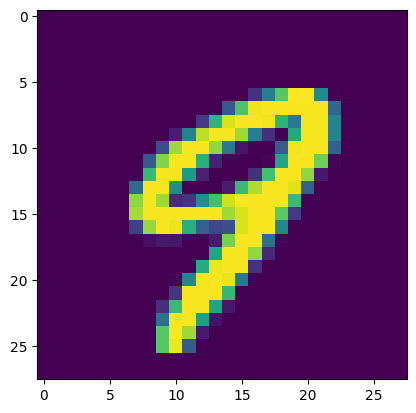

In [5]:
plt.imshow(df.iloc[33707, 1:].values.reshape(28, 28))

In [6]:
X = df.drop(columns=["label"])
y = df.label

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape

(33600, 784)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy_score(y_test, y_pred)

0.9648809523809524

In [10]:
scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.fit(X_test)